# Deep Learning with Python - 3th ed.
Francois Chollet
Matthew Watson


<img src="../pics/cover_DeepLearning.jpg" width=400> 

https://github.com/fchollet/deep-learning-with-python-notebooks

https://github.com/cr2003/BK_DeepLearning_with_Python_3ed



<a href="file:///C:/Users/crodr/OneDrive/InterChange/Books/Tech/DeepLearnig/Deep Learning with Python, Third Edition (François Chollet, Matthew Watson) (z-library.sk, 1lib.sk, z-lib.sk).pdf" target="_blank">Abrir PDF Local</a>

In [3]:
import os

# Definimos la ruta de tu libro
ruta_libro = r"C:\Users\crodr\OneDrive\InterChange\Books\Tech\DeepLearnig\Deep Learning with Python, Third Edition (François Chollet, Matthew Watson) (z-library.sk, 1lib.sk, z-lib.sk).pdf"

# Esto le dice a Windows: "Abre este archivo con el programa por defecto del sistema"
os.startfile(ruta_libro)

In [1]:
!pwd

/c/Users/crodr/BK_tech/DeepLearning/BK_DeepLearning_with_Python_3ed/ch03


In [2]:
!python --version

Python 3.12.10


# Chapter 03 - Introduction to TensorFlow, PyTorch, JAX, and Keras
## 3.4 Introduction to PyTorch
### 3.4.1 First steps with TensorFlow
page 75

#### Tensors and Parameters in PyTorch
A first gotcha about PyTorch is that the package isn’t named pytorch. It’s actually named
torch. You’d install it via pip install torch and you’d import it via import torch.
Like in NumPy and TensorFlow, the object at the heart of the framework is the tensor.
First, let’s get our hands on some PyTorch tensors.

##### Constant Tensors

Here are some constant tensors.


In [2]:
import torch

# unlike in other frameworks, the shape argument is named "size" rather than "shape"
torch.ones(size=(2, 1))

tensor([[1.],
        [1.]])

In [3]:
torch.zeros(size=(2, 1))

tensor([[0.],
        [0.]])

In [4]:
# unlike in other frameworks, you cannot pass dtype="float32" as a string. The dtype argument must be a torch dtype instance
torch.tensor([1, 2, 3], dtype=torch.float32)

tensor([1., 2., 3.])

#### Random Tensors
Random tensor creation is similar to NumPy and TensorFlow, but with divergent syntax.
Consider the function normal: it doesn’t take a shape argument. Instead, the mean
and standard deviation should be provided as PyTorch tensors with the expected output
shape.

In [5]:
# Equivalent to tf.random.normal(shape=3,1), mean=0.,stddev=1.
torch.normal(mean=torch.zeros(size=(3, 1)), std=torch.ones(size=(3, 1)))

tensor([[-0.1054],
        [ 0.2340],
        [ 0.2735]])

As for creating a random uniform tensor, you’d do that via `torch.rand`. Unlike `np.random.uniform`
or `tf.random.uniform`, the output shape should be provided as independent
arguments for each dimension, like this:

In [6]:
# Equivalent to tf.random.uniform(shape=(3,1),minval=0.,maxval=1.)
torch.rand(3, 1)

tensor([[0.7044],
        [0.1269],
        [0.3050]])

#### Tensor Assignment and the Parameter Class
Like NumPy arrays, but unlike TensorFlow tensors, PyTorch tensors are assignable. You
can do operations like this:

In [7]:
x = torch.zeros(size=(2, 1))
x[0, 0] = 1
x

tensor([[1.],
        [0.]])

While you can just use a regular `torch.Tensor` to store the trainable state of a model,
PyTorch does provide a specialized tensor subclass for that purpose, the `torch.nn.parameter.Parameter` class. 
Compared to a regular tensor, it provides semantic
clarity—if you see a `Parameter`, you’ll know it’s a piece of trainable state, whereas a
Tensor could be anything. As a result, it enables PyTorch to automatically track and
retrieve the `Parameters` you assign to PyTorch models—similar to what Keras does with
Keras `Variable` instances.

Here’s a `Parameter`.

In [8]:
x = torch.zeros(size=(2, 1))

# A parameter can only be created using a torch.Tensor value-no NumPy arrays allowed
p = torch.nn.parameter.Parameter(data=x)

print(x)
print(p)

tensor([[0.],
        [0.]])
Parameter containing:
tensor([[0.],
        [0.]], requires_grad=True)


#### Tensor Operations: Doing math in PyTorch

Math in PyTorch works just the same as math in NumPy or TensorFlow, although much
like TensorFlow, the PyTorch API often diverges in subtle ways from the NumPy API.

In [9]:
a = torch.ones((2, 2))
b = torch.square(a)  # takes the square, same as np.square
b

tensor([[1., 1.],
        [1., 1.]])

In [10]:
c = torch.sqrt(a)  # takes the square root, , same as np.sqrt
c

tensor([[1., 1.],
        [1., 1.]])

In [ ]:
d = b + c  # adds two tensors (elment-wise)
d

tensor([[2., 2.],
        [2., 2.]])

In [ ]:
e = torch.matmul(a, b)  # takes the product of two tensors, same as np.matmul
e

tensor([[2., 2.],
        [2., 2.]])

In [ ]:
f = torch.cat(
    (a, b), dim=0
)  # Concatenates a and b along axis 0, same as np.concatenate
f

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])

Here's a dense layer

In [10]:
def dense(inputs, W, b):
    return torch.nn.relu(torch.matmul(inputs, W) + b)

#### Computing Gradients with PyTorch

There’s no explicit “gradient tape” in PyTorch. A similar mechanism does exist: when
you run any computation in PyTorch, the framework creates a one-time computation
graph (a “tape”) that records what just happened. However, that tape is hidden from
the user. The public API for using it is at the level of tensors themselves: you can call
tensor.backward() to run backpropagation through all operations previously executed
that led to that tensor. Doing this will populate the .grad attribute of all tensors
that are tracking gradients.

In [11]:
# To compute gradients with respect a tensor, it must be created with requires_gra=True
input_var = torch.tensor(3.0, requires_grad=True)
result = torch.square(input_var)

# Calling backward() populates the "grad" attribute on all tensors create with requires_grad=True
result.backward()
gradient = input_var.grad
gradient

tensor(6.)

If you call `backward()` multiple times in a row, the `.grad` attribute will “accumulate” gradients:
each new call will sum the new gradient with the preexisting one. For instance,
in the following code, `input_var.grad` is not the gradient of `square(input_var)` with
respect to `input_var`; rather, it is the sum of that gradient and the previously computed
gradient—its value has doubled since our last code snippet:

In [12]:
result = torch.square(input_var)
result.backward()

# .grad will sum all gradient values from each time backward() is called
input_var.grad

tensor(12.)

To reset gradients, you can just set `.grad` to `None`

In [13]:
input_var.grad = None
print(input_var.grad)

None


### 3.4.2 An end-to-end example: A linear classifier in pure PyTorch
Previously, like we did in 3.3.2 we must create the synthetic data:


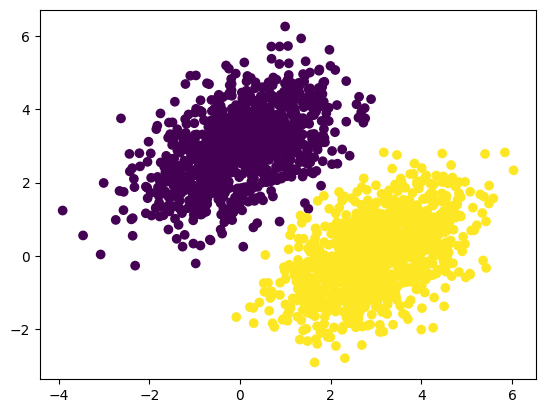

In [14]:
import numpy as np

num_samples_per_class = 1_000

# Generates the first class of points: 1_000 random 2D points with specified "mean" and "covariance" matrix.
# Intuitively, the "covariance matrix" describes the shape of the point cloud, and the "mean" describes its
# position in the plan.cov=[[1, 0.5], [0.5, 1]] corrresponds to "an oval-like point cloud oriented from bottom
# left to top right."
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)

# Generates the other class of points with a different mean and the same covariance matrix (point cloud with a
# different poistion and the same shape)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)

inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)
inputs.shape

targets = np.vstack(
    (
        np.zeros((num_samples_per_class, 1), dtype="float32"),
        np.ones((num_samples_per_class, 1), dtype="float32"),
    )
)

import matplotlib.pyplot as plt

plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.show()


You now know enough to rewrite our linear classifier in PyTorch. It will stay very similar
to the TensorFlow one—the only major difference is how we compute the gradients.
Let’s start by creating our model variables. Don’t forget to pass `requires_grad=True`
so we can compute gradients with respect to them:

In [16]:
input_dim = 2
output_dim = 1

W = torch.rand(input_dim, output_dim, requires_grad=True)
b = torch.zeros(output_dim, requires_grad=True)


This is our model—no difference so far. We just went from `tf.matmul` to `torch.matmul`:

In [17]:
def model(inputs, W, b):
    return torch.matmul(inputs, W) + b

This is our loss function. We just switch from `tf.square` to `torch.square` and from
`tf.reduce_mean` to `torch.mean`:

In [18]:
def mean_squared_error(targets, predictions):
    per_sample_losses = torch.square(targets - predictions)
    return torch.mean(per_sample_losses)

Now for the training step. Here’s how it works:

1. `loss.backward()` runs backpropagation starting from the `loss` output node and
populates the `tensor.grad` attribute on all tensors that were involved in the computation
of `loss`. `tensor.grad` represents the gradient of the loss with regard to
that tensor.

2.  We use the `.grad` attribute to recover the gradients of the loss with regard to `W` and `b`.

3.  We update `W` and `b` using those gradients. Because these updates are not intended
to be part of the backward pass, we do them inside a `torch.no_grad()` scope,
which skips gradient computation for everything inside it.

4.  We reset the contents of the `.grad` property of our `W` and `b` parameters, by setting
it to `None`. If we didn’t do this, gradient values would accumulate across multiple
calls to `training_step()`, resulting in invalid values:


In [19]:
learning_rate = 0.1


def training_step(inputs, targets, W, b):

    # Forward pass
    predictions = model(inputs)
    loss = mean_squared_error(targets, predictions)

    # Computes gradients
    loss.backward()

    # Retrieves gradients
    grad_loss_wrt_W, grad_loss_wrt_b = W.grad, b.grad

    with torch.no_grad():
        # Updates weights inside a no_grad scope
        W -= grad_loss_wrt_W * learning_rate
        b -= grad_loss_wrt_b * learning_rate

    # Reset gradients
    W.grad = None
    b.grad = None
    return loss


This could be made even simpler--let's see how.

#### Packaging State and Computation with the Module Class

PyTorch also has a higher-level, object-oriented API for performing backpropagation,
which requires relying on two new classes: the `torch.nn.Module` class and an optimizer
class from the `torch.optim` module, such as `torch.optim.SGD` (the equivalent of keras
`.optimizers.SGD`).

The general idea is to define a subclass of `torch.nn.Module`, which will

* Hold some `Parameters`, to store state variables. Those are defined in the
`__init__()` method.

* Implement the forward pass computation in the `forward()` method.

It should look just like the following.

In [20]:
class LinearModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.W = torch.nn.Parameter(torch.rand(input_dim, output_dim))
        self.b = torch.nn.Parameter(torch.zeros(output_dim))

    def forward(self, inputs):
        return torch.matmul(inputs, self.W) + self.b


We can now instantiate our `LinearModel`:

In [21]:
model = LinearModel()

When using an instance of `torch.nn.Module`, rather than calling the `forward()` method
directly, you’d use `__call__()` (i.e., directly call the model class on inputs), which redirects
to `forward()` but adds a few framework hooks to it:

In [22]:
torch_inputs = torch.tensor(inputs)
output = model(torch_inputs)

Now, let’s get our hands on a PyTorch optimizer. To instantiate it, you will need to provide
the list of parameters that the optimizer is intended to update. You can retrieve it
from our Module instance via `.parameters()`:

In [23]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

Using our Module instance and the PyTorch SGD optimizer, we can run a simplified
training step:

In [ ]:
# NEW
def training_step(inputs, targets):
    predictions = model(inputs)
    loss = mean_squared_error(targets, predictions)
    loss.backward()
    optimizer.step()
    model.zero_grad()
    return loss


torch_inputs = torch.tensor(inputs)
torch_targets = torch.tensor(targets)

for step in range(40):
    loss = training_step(torch_inputs, torch_targets)
    print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 2.3934
Loss at step 1: 0.3524
Loss at step 2: 0.1533
Loss at step 3: 0.1233
Loss at step 4: 0.1126
Loss at step 5: 0.1047
Loss at step 6: 0.0977
Loss at step 7: 0.0913
Loss at step 8: 0.0855
Loss at step 9: 0.0802
Loss at step 10: 0.0754
Loss at step 11: 0.0710
Loss at step 12: 0.0670
Loss at step 13: 0.0634
Loss at step 14: 0.0601
Loss at step 15: 0.0570
Loss at step 16: 0.0543
Loss at step 17: 0.0518
Loss at step 18: 0.0495
Loss at step 19: 0.0474
Loss at step 20: 0.0455
Loss at step 21: 0.0438
Loss at step 22: 0.0422
Loss at step 23: 0.0408
Loss at step 24: 0.0395
Loss at step 25: 0.0383
Loss at step 26: 0.0372
Loss at step 27: 0.0362
Loss at step 28: 0.0353
Loss at step 29: 0.0345
Loss at step 30: 0.0338
Loss at step 31: 0.0331
Loss at step 32: 0.0325
Loss at step 33: 0.0319
Loss at step 34: 0.0314
Loss at step 35: 0.0309
Loss at step 36: 0.0305
Loss at step 37: 0.0301
Loss at step 38: 0.0298
Loss at step 39: 0.0294


Prevously, updating the model parameters look like this:
```python 
    with torch.no_grad():
        W -= grad_loss_wrt_W * learning_rate
        b -= grad_loss_wrt_b * learning_rate

```

Now we can just do `optimizer.step()`.

Similarly, previously we needed to reset parameter gradients by hand by doing
`tensor.grad = None` on each one. Now we can just do `model.zero_grad()`.
Overall, this may feel a bit confusing—somehow the loss tensor, the optimizer, and
the `Module` instance all seem to be aware of each other through some hidden background
mechanism. They’re all interacting with one another via spooky action at a distance.
Don’t worry though—you can just treat this sequence of steps 
(`loss.backward() - optimizer.step() - model.zero_grad()`) as a magic incantation to be recited any time
you need to write a training step function. Just make sure not to forget `model.zero_grad()`. 
That would be a major bug (and it is unfortunately quite common)!

#### Reproducir el modelo

Kye differences compared to the TensorFlow version:

* `detach().numpy` — In Pytorch, tesors with `requires_grad=True` cannot be directly converted to NumPy; they must first be detached from the computational graph.

* `model.W / model.b` — The parameters reside within the module; they are not separate variables as in TensorFlow.

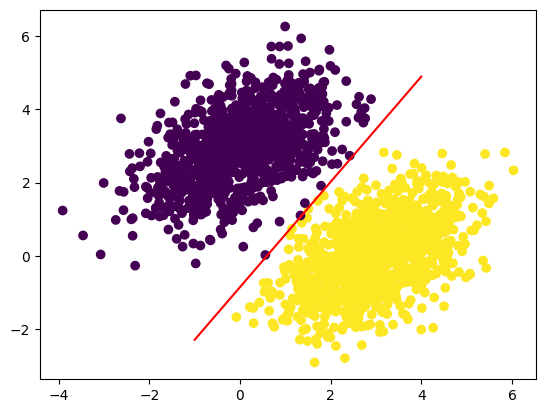

In [31]:
predictions = model(torch_inputs)  # ← recalcular con el modelo entrenado

# separation line
W_np = model.W.detach().numpy()
b_np = model.b.detach().numpy()
x = np.linspace(-1, 4, 100)
y = -W_np[0] / W_np[1] * x + (0.5 - b_np) / W_np[1]
plt.plot(x, y, "-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0].detach().numpy() > 0.5)
plt.show()


#### Making PyTorch Modules Fast using Compilation

One last thing. Similarly to how TensorFlow lets you compile functions for better performance,
PyTorch lets you compile functions or even Module instances via the `torch.compile()` utility. 
This API uses PyTorch’s very own compiler, named Dynamo.

Let’s try it on our linear regression Module:

In [32]:
compiled_model = torch.compile(model)

The resulting object is intended to work identically to the original—except the forward
and backward pass should run faster.

You can also use `torch.compile()` as a function decorator:

In [ ]:
@torch.compile
def dense(inputs, W, b):
    return torch.nn.relu(torch.matmul(inputs, W) + b)

In practice, most PyTorch code out there does not use compilation and simply runs
eagerly, as the compiler may not always work with all models and may not always result
in a speedup when it does work. Unlike in TensorFlow and Jax where compilation
was built in from the inception of the library, PyTorch’s compiler is a relatively recent
addition.